In [1]:
! pip install kaggle

In [2]:
# 3. Create the Kaggle directory and move the file there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
# Change permissions so no one else can read your API key
!chmod 600 ~/.kaggle/kaggle.json

# 4. Download the Amazon Fine Food Reviews dataset
print("\nDownloading the Amazon dataset...")
!kaggle datasets download -d snap/amazon-fine-food-reviews

# 5. Unzip the downloaded file
print("Unzipping the data...")
!unzip -q amazon-fine-food-reviews.zip


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory

Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
License(s): CC0-1.0
100% 242M/242M [00:01<00:00, 164MB/s]

Unzipping the data...


In [3]:
import pandas as pd
from transformers import pipeline
from tqdm.notebook import tqdm

# Enable a progress bar for pandas (useful so you know it hasn't frozen!)
tqdm.pandas()

# 1. Load the dataset you collected in the previous step
df_hn = pd.read_csv("/content/Reviews.csv")
df_hn=df_hn.loc[0:5,:]


print(df_hn.shape)

(6, 10)


In [4]:
df_hn.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...


In [5]:

import pandas as pd
from transformers import pipeline
from tqdm import tqdm

tqdm.pandas()

# 2. Load your data
df_hn = pd.read_csv("/content/Reviews.csv")

# 3. Combine Summary + Text
df_hn['Full_Text'] = df_hn['Summary'].fillna('') + " " + df_hn['Text'].fillna('')

# 4. Load DeBERTa model
print("Downloading and loading DeBERTa model (this may take a minute)...")

model_name = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
classifier = pipeline("zero-shot-classification", model=model_name)

# 5. Define labels
candidate_labels = ["Positive", "Negative", "Neutral"]

# 6. Sentiment function
def get_deberta_sentiment(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return "Neutral", 0.0

    result = classifier(text[:512], candidate_labels)

    return result['labels'][0], result['scores'][0]


print("Analyzing sentiment for 100 records...")

df_sample = df_hn.head(10).copy()

df_sample[['Sentiment', 'Confidence_Score']] = df_sample['Full_Text'].progress_apply(
    lambda x: pd.Series(get_deberta_sentiment(x))
)

# 8. Save result
df_sample.to_csv("/content/reivews_sentiment_analysis.csv", index=False)

print("✅ Done! File saved as final_deberta_sentiment_analysis.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Analyzing sentiment for 100 records...


100%|██████████| 10/10 [01:56<00:00, 11.60s/it]

✅ Done! File saved as final_deberta_sentiment_analysis.csv


In [6]:
df_hn.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Full_Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Good Quality Dog Food I have bought several of...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised Product arrived labeled as J...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,"""Delight"" says it all This is a confection tha..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Cough Medicine If you are looking for the secr...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Great taffy Great taffy at a great price. The...


/tmp/ipykernel_7804/1285725726.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


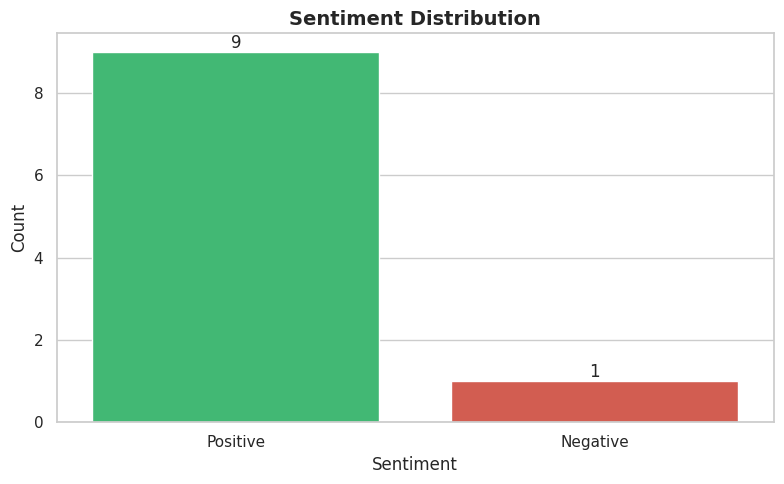

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

sentiment_colors = {
    "Positive": "#2ecc71",
    "Neutral": "#95a5a6",
    "Negative": "#e74c3c"
}

ax = sns.countplot(
    data=df_sample,
    x='Sentiment',
    order=df_sample['Sentiment'].value_counts().index,
    palette=sentiment_colors
)

plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()